In [1]:
import requests
import pandas as pd
from datetime import datetime
import os
import time

sites = {
    "NASA Goddard": (38.9977, -76.8525),
    "HU IRB":       (38.9193, -77.0215),
    "SERC":         (38.890131, -76.560014),
}

parameters = [
    "temperature_2m", 
    "relative_humidity_2m", 
    "precipitation", 
    "wind_speed_10m",
    "wind_direction_10m"
]

def fetch_site(site_name, lat, lon, years):
    all_data = []

    for year in years:
        for month in range(1, 13):
            start_date = datetime(year, month, 1).strftime("%Y-%m-%d")
            end_date = datetime(year + 1, 1, 1).strftime("%Y-%m-%d") if month == 12 \
                       else datetime(year, month + 1, 1).strftime("%Y-%m-%d")

            params = {
                "latitude": lat,
                "longitude": lon,
                "start_date": start_date,
                "end_date": end_date,
                "hourly": ",".join(parameters),
                "timezone": "auto"
            }

            print(f"  {site_name} | {start_date} to {end_date}")
            response = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params)

            if response.status_code != 200:
                print(f"  x HTTP {response.status_code}, skipping")
                continue

            data = response.json()
            if "hourly" not in data:
                print(f"  x No hourly data, skipping")
                continue

            df = pd.DataFrame(data["hourly"])
            df["Site"] = site_name
            all_data.append(df)
            time.sleep(0.5)

    if not all_data:
        print(f"  No data collected for {site_name}")
        return

    final_df = pd.concat(all_data, ignore_index=True)
    final_df.rename(columns={"time": "DateTime"}, inplace=True)
    final_df["DateTime"] = pd.to_datetime(final_df["DateTime"])

    out_dir = os.path.join("..", "..", "data", "metero")
    os.makedirs(out_dir, exist_ok=True)

    safe_name = site_name.replace(" ", "_")
    out_path = os.path.join(out_dir, f"{safe_name}_hourly_meteo.csv")
    final_df.to_csv(out_path, index=False)
    print(f"  v Saved {len(final_df)} rows to {out_path}\n")


for site_name, (lat, lon) in sites.items():
    fetch_site(site_name, lat, lon, years=[2020, 2021, 2022, 2023, 2024])

  NASA Goddard | 2020-01-01 to 2020-02-01
  NASA Goddard | 2020-02-01 to 2020-03-01
  NASA Goddard | 2020-03-01 to 2020-04-01
  NASA Goddard | 2020-04-01 to 2020-05-01
  NASA Goddard | 2020-05-01 to 2020-06-01
  NASA Goddard | 2020-06-01 to 2020-07-01
  NASA Goddard | 2020-07-01 to 2020-08-01
  NASA Goddard | 2020-08-01 to 2020-09-01
  NASA Goddard | 2020-09-01 to 2020-10-01
  NASA Goddard | 2020-10-01 to 2020-11-01
  NASA Goddard | 2020-11-01 to 2020-12-01
  NASA Goddard | 2020-12-01 to 2021-01-01
  NASA Goddard | 2021-01-01 to 2021-02-01
  NASA Goddard | 2021-02-01 to 2021-03-01
  NASA Goddard | 2021-03-01 to 2021-04-01
  NASA Goddard | 2021-04-01 to 2021-05-01
  NASA Goddard | 2021-05-01 to 2021-06-01
  NASA Goddard | 2021-06-01 to 2021-07-01
  NASA Goddard | 2021-07-01 to 2021-08-01
  NASA Goddard | 2021-08-01 to 2021-09-01
  NASA Goddard | 2021-09-01 to 2021-10-01
  NASA Goddard | 2021-10-01 to 2021-11-01
  NASA Goddard | 2021-11-01 to 2021-12-01
  NASA Goddard | 2021-12-01 to 202

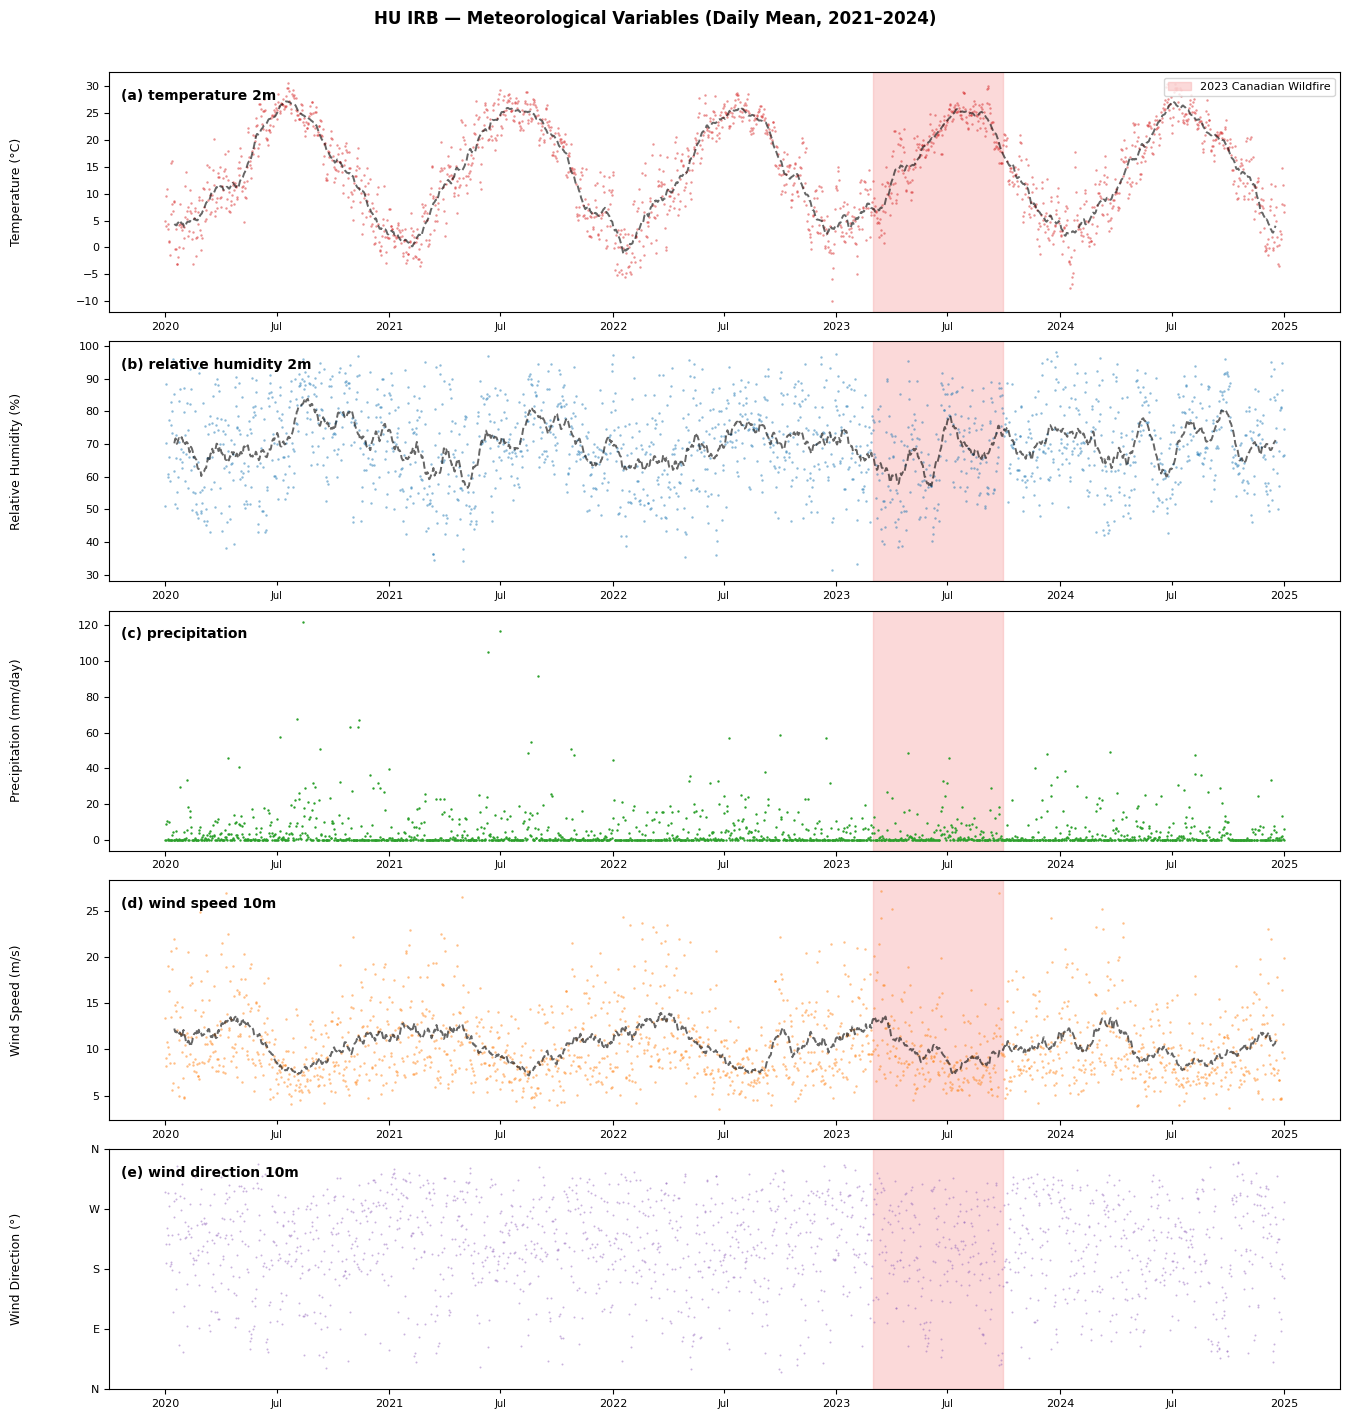

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Load ---
df = pd.read_csv("../../data/metero/HU_IRB_hourly_meteo.csv", parse_dates=["DateTime"])
df = df.sort_values("DateTime")

# Daily resample for cleaner seasonality view
daily = df.resample("D", on="DateTime").agg({
    "temperature_2m":       "mean",
    "relative_humidity_2m": "mean",
    "precipitation":        "sum",
    "wind_speed_10m":       "mean",
    "wind_direction_10m":   "mean",
})

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

variables = [
    ("temperature_2m",       "Temperature (°C)",       "#d62728"),
    ("relative_humidity_2m", "Relative Humidity (%)",  "#1f77b4"),
    ("precipitation",        "Precipitation (mm/day)", "#2ca02c"),
    ("wind_speed_10m",       "Wind Speed (m/s)",       "#ff7f0e"),
    ("wind_direction_10m",   "Wind Direction (°)",     "#9467bd"),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
labels = [f"({chr(97+i)})" for i in range(5)]

for ax, (col, ylabel, color), label in zip(axes, variables, labels):
    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.5, zorder=0, label="2023 Canadian Wildfire")

    if col == "precipitation":
        # ax.bar(daily.index, daily[col], width=1, color=color, alpha=0.7, zorder=2)
        ax.scatter(daily.index, daily[col],
                   s=3, color=color, alpha=1, linewidths=0, zorder=2)
    elif col == "wind_direction_10m":
        ax.scatter(daily.index, daily[col],
                   s=2, color=color, alpha=0.5, linewidths=0, zorder=2)
        ax.set_ylim(0, 360)
        ax.set_yticks([0, 90, 180, 270, 360])
        ax.set_yticklabels(["N", "E", "S", "W", "N"])
    else:
        # ax.plot(daily.index, daily[col], color=color, linewidth=0.8, alpha=0.85, zorder=2)
        ax.scatter(daily.index, daily[col],
                   s=3, color=color, alpha=0.5, linewidths=0, zorder=2)


    # 30-day rolling mean overlay (except precipitation and wind direction)
    if col not in ("precipitation", "wind_direction_10m"):
        roll = daily[col].rolling(30, center=True).mean()
        ax.plot(daily.index, roll, color="black", linewidth=1.4, zorder=3, linestyle="--", alpha=0.6)

    ax.set_ylabel(ylabel, fontsize=9)
    ax.text(0.01, 0.93, f"{label} {col.replace('_', ' ')}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top")
    ax.tick_params(labelsize=8)
    ax.yaxis.set_label_coords(-0.07, 0.5)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=8, frameon=True, framealpha=0.8)

# X-axis ticks: Jan (year) + Jul on all subplots
def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jul"

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))
    ax.tick_params(axis="x", which="major", labelsize=8, labelbottom=True)
    fig.canvas.draw()
    for tick in ax.xaxis.get_major_ticks():
        if tick.label1.get_text() == "Jul":
            tick.tick1line.set_markersize(3)
            tick.tick2line.set_markersize(3)
            tick.label1.set_fontsize(7)

fig.suptitle("HU IRB — Meteorological Variables (Daily Mean, 2021–2024)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.11)
# plt.savefig("../../data/HU_IRB_meteo_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()
